# Introduction
this project is about making a machine learning model to detect disaster and non-disaster tweets.

Importing the libraries

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import scipy as stats 

In [92]:
from sklearn.model_selection import train_test_split
from collections import Counter

Loading the data

In [93]:
df = pd.read_csv("twitter_disaster (1).csv")

In [94]:
df.shape

(7613, 5)

In [95]:
print(df.head())
print(df.tail())

   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  
         id keyword location  \
7608  10869     NaN      NaN   
7609  10870     NaN      NaN   
7610  10871     NaN      NaN   
7611  10872     NaN      NaN   
7612  10873     NaN      NaN   

                                                   text  target  
7608  Two giant cranes holding a bridge collapse int...       1  
7609  @aria_ahrary @TheTawniest The out of control w...       1  
7610  M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...       1  
7611  Po

Checking the class balance

In [96]:
print(df['target'].value_counts())

target
0    4342
1    3271
Name: count, dtype: int64


There are more non-disaster tweets than disaster related tweets.

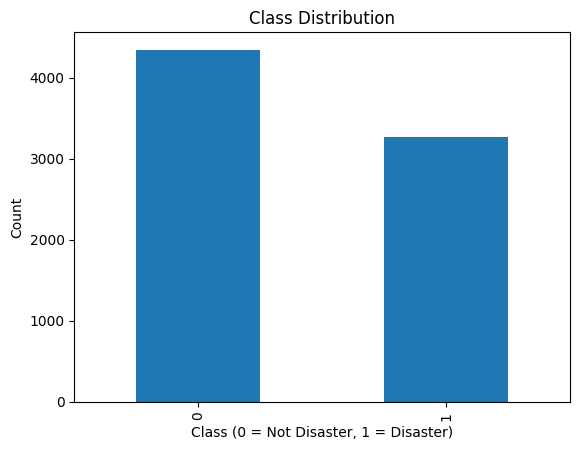

In [97]:
df['target'].value_counts().plot(kind='bar')
plt.xlabel('Class (0 = Not Disaster, 1 = Disaster)')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


Missing Values

In [99]:
df.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Handling missing values

In [100]:
df['keyword'] = df['keyword'].fillna('unknown')
df['location'] = df['location'].fillna('unknown')

In [101]:
df.isnull().sum()

id          0
keyword     0
location    0
text        0
target      0
dtype: int64

### Cleaning text
Removing hashtags, turning all words into lower case, removing punctuations and numbers along with removing mentions and URLs

In [102]:
import re
import string
import nltk
import emoji

In [103]:
%pip install nltk emoji


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [104]:
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [105]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
 

In [106]:
STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

Precompiled regex patterns

In [107]:
URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')
MENTION_PATTERN = re.compile(r'@\w+')
HASHTAG_SYMBOL_PATTERN = re.compile(r'#')
NUMBER_PATTERN = re.compile(r'\d+')
PUNCT_TABLE = str.maketrans('', '', string.punctuation)

In [108]:
def convert_emojis_to_text(text: str) -> str:
    """Turn emojis into readable words, e.g. '🔥' -> 'fire'."""
    text = emoji.demojize(text, delimiters=(' ', ' '))
    # demojize gives things like " fire " or " loudly_crying_face "
    text = text.replace('_', ' ')
    return text

In [109]:
def clean_text(text: str, use_stemming: bool = False) -> str:
    """Clean a single tweet and return the processed string."""
    if not isinstance(text, str):
        return ''

In [120]:
def clean_text(text):
    text = text.lower()
    text = text.replace('&amp;', ' ')
    text = URL_PATTERN.sub('', text)
    text = MENTION_PATTERN.sub('', text)
    text = HASHTAG_SYMBOL_PATTERN.sub('', text)
    text = NUMBER_PATTERN.sub('', text)
    text = text.translate(PUNCT_TABLE)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

df['tokens'] = df['text'].apply(clean_text)
df['clean_text'] = df['tokens'].apply(lambda t: ' '.join(t))

df[['text', 'tokens', 'clean_text']].head(3)

,text,tokens,clean_text
0,Our Deeds are the Reason of this #earthquake M...,"[deed, reason, earthquake, may, allah, forgive...",deed reason earthquake may allah forgive u
1,Forest fire near La Ronge Sask. Canada,"[forest, fire, near, la, ronge, sask, canada]",forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,"[resident, asked, shelter, place, notified, of...",resident asked shelter place notified officer ...


In [113]:
df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text', 'target']].head()

,text,clean_text,target
0,Our Deeds are the Reason of this #earthquake M...,deed reason earthquake may allah forgive u,1
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,1
2,All residents asked to 'shelter in place' are ...,resident asked shelter place notified officer ...,1
3,"13,000 people receive #wildfires evacuation or...",people receive wildfire evacuation order calif...,1
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo ruby alaska smoke wildfire pour...,1


## Most Frequent words before and after cleaning

In [114]:
def top_words(text_series, n=15):
    all_words = ' '.join(text_series.astype(str)).split()
    return pd.DataFrame(Counter(all_words).most_common(n), columns=['word', 'count'])

before_df = top_words(df['text'])
after_df = top_words(df['clean_text'])

print("BEFORE cleaning:")
print(before_df)

print("AFTER cleaning:")
print(after_df)

BEFORE cleaning:
    word  count
0    the   2575
1      a   1845
2     to   1805
3     in   1757
4     of   1722
5    and   1302
6      I   1197
7    for    820
8     is    814
9     on    773
10     -    763
11   you    632
12   The    552
13    my    549
14  with    508
AFTER cleaning:
         word  count
0        fire    351
1        like    347
2         amp    300
3          im    299
4         get    255
5           u    254
6         new    224
7         via    220
8         one    205
9      people    198
10       news    195
11       dont    191
12      video    174
13       time    173
14  emergency    158


In [115]:
print(df['target'].dtype)

int64


In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['target'],
    test_size=0.2,
    random_state=42,
    stratify=df['target']
)

print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

Train size: 6090
Test size: 1523


In [117]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)      # keep the 5000 most informative words
X_train_tfidf = tfidf.fit_transform(X_train)    # learn vocabulary + transform training data
X_test_tfidf = tfidf.transform(X_test)          # ONLY transform — reuse the same vocabulary

print(X_train_tfidf.shape)   # (6090, 5000)
print(X_test_tfidf.shape)    # (1523, 5000)

(6090, 5000)
(1523, 5000)


## Cell - Extra features

In [118]:
df['tweet_length'] = df['text'].apply(len)
df['has_hashtag'] = df['text'].str.contains('#').astype(int)
df['has_mention'] = df['text'].str.contains('@').astype(int)

### Combine TF-IDF with the extra features
Without this step, your model would only ever see word content (TF-IDF) and never see things like "this tweet is unusually long" or "this tweet has a hashtag"

In [121]:
from scipy.sparse import hstack

extra_cols = ['tweet_length', 'has_hashtag', 'has_mention']
X_train_extra = df.loc[X_train.index, extra_cols]
X_test_extra  = df.loc[X_test.index, extra_cols]

X_train_combined = hstack([X_train_tfidf, X_train_extra.values])
X_test_combined  = hstack([X_test_tfidf, X_test_extra.values])

print(X_train_combined.shape)   
print(X_test_combined.shape)    

(6090, 5003)
(1523, 5003)


## Logistic Regression

In [122]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_combined, y_train)

cv_scores = cross_val_score(log_reg, X_train_combined, y_train, cv=5, scoring='accuracy')
print('CV accuracy scores:', cv_scores)
print('Mean CV accuracy:', cv_scores.mean())
print('Std dev:', cv_scores.std())

CV accuracy scores: [0.81116585 0.79392447 0.78243021 0.7955665  0.78899836]
Mean CV accuracy: 0.7944170771756979
Std dev: 0.009540780982813768


## Random Forest

In [123]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_combined, y_train)

cv_scores_rf = cross_val_score(rf, X_train_combined, y_train, cv=5, scoring='accuracy')
print('RF CV accuracy scores:', cv_scores_rf)
print('Mean CV accuracy:', cv_scores_rf.mean())

RF CV accuracy scores: [0.79064039 0.7865353  0.7635468  0.7816092  0.78078818]
Mean CV accuracy: 0.780623973727422


## Comapring the models

In [126]:
from sklearn.metrics import classification_report, confusion_matrix

pred_lr = log_reg.predict(X_test_combined)
pred_rf = rf.predict(X_test_combined)

print("Logistic Regression :")
print(classification_report(y_test, pred_lr, target_names=['Not Disaster', 'Disaster']))
print(confusion_matrix(y_test, pred_lr))

print("Random Forest :")
print(classification_report(y_test, pred_rf, target_names=['Not Disaster', 'Disaster']))
print(confusion_matrix(y_test, pred_rf))

Logistic Regression :
              precision    recall  f1-score   support

Not Disaster       0.80      0.87      0.84       869
    Disaster       0.81      0.72      0.76       654

    accuracy                           0.81      1523
   macro avg       0.81      0.80      0.80      1523
weighted avg       0.81      0.81      0.81      1523

[[760 109]
 [185 469]]
Random Forest :
              precision    recall  f1-score   support

Not Disaster       0.79      0.89      0.84       869
    Disaster       0.82      0.69      0.75       654

    accuracy                           0.80      1523
   macro avg       0.81      0.79      0.79      1523
weighted avg       0.81      0.80      0.80      1523

[[773  96]
 [203 451]]


Logistic regression has more accuracy.

In [127]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['liblinear']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train_combined, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV F1 score:', grid_search.best_score_)

Best params: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1 score: 0.736593303639653


c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### ROC Curve

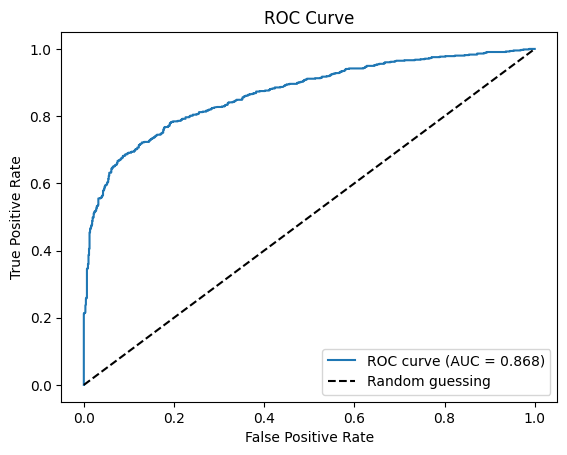

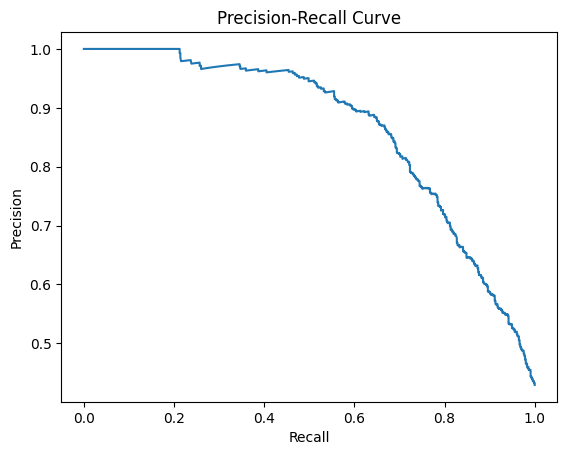

Train accuracy: 0.8750410509031199
Test accuracy: 0.8069599474720945


In [128]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, accuracy_score

y_proba = log_reg.predict_proba(X_test_combined)[:, 1]

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_proba)
plt.plot(rec, prec)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

# Overfitting check
train_acc = accuracy_score(y_train, log_reg.predict(X_train_combined))
test_acc = accuracy_score(y_test, log_reg.predict(X_test_combined))
print('Train accuracy:', train_acc)
print('Test accuracy:', test_acc)

In [129]:
import pickle

# Retrain on the full dataset before saving — since we've already validated
# the model on train/test, we use all available data for the final version
tfidf_final = TfidfVectorizer(max_features=5000)
X_all_tfidf = tfidf_final.fit_transform(df['clean_text'])
X_all_extra = df[['tweet_length', 'has_hashtag', 'has_mention']].values
X_all_combined = hstack([X_all_tfidf, X_all_extra])

final_model = LogisticRegression(max_iter=1000, C=1)
final_model.fit(X_all_combined, df['target'])

with open('disaster_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_final, f)

print('Model and vectorizer saved — ready for deployment in app.py')

Model and vectorizer saved — ready for deployment in app.py
